#### 1. Setup MODE
- Prints the repo root path (e.g.../Automation/ode-workflow)
  
- MODE options:
    - run_missing: skip runs that already have "run_summary.json" file
    - overwrite: rerun everything even if outputs exist
    - load_only: just read existing summaries (no simulation)

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))
print("repo_root:", repo_root)


import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.run_sweep import run_sweep, load_config

# Choose model: "Kapitanov" or "Walz"
MODEL = "Walz" 

# Choose mode: "run_missing", "overwrite", "load_only"
MODE = "run_missing"

# Parallelism (good default for ~40 runs)
workers = 8  # adjust for your machine; 4–8 is typical




config_path = repo_root / "configs" / (f"{MODEL}_sweep.yaml" if MODEL == "Walz" else "Kapitanov_sweep.yaml")
print("Using config:", config_path)


repo_root: C:\Users\LevinSchöpfer\Automation\ode-workflow


C:\Temp\miniforge3\envs\ode-sim\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Using config: C:\Users\LevinSchöpfer\Automation\ode-workflow\configs\Walz_sweep.yaml


#### 2. Define parameters + RUN
- Input:
    - dose_values in mg/kg
    - interval_values in weeks (integers only)


- Run:
    - Expected runs should match found runs
    - Prints missing items, if present 

In [2]:

# -------------------------
# INPUT
# -------------------------


def geometric_series(lower, upper, n, decimals=1):
    if lower <= 0 or upper <= 0:
        raise ValueError("Bounds must be > 0 for a geometric series.")
    if n < 2:
        raise ValueError("n must be at least 2.")
    r = (upper / lower) ** (1 / (n - 1))
    vals = [round(lower * r**i, decimals) for i in range(n)]
    vals = sorted(set(vals))
    return vals

dose_spec = [0.05, 80, 20]  # lower, upper, n
dose_values = geometric_series(*dose_spec, decimals=1)

interval_values = [2, 4, 8, 12]  # weeks (int only)

print("Dose values:", dose_values)
print("Intervals:", interval_values)
print("Expected runs:", len(dose_values) * len(interval_values))




# -------------------------
# RUN / LOAD
# -------------------------


cfg = load_config(config_path)
out_root = repo_root / cfg["output"]["root_dir"]

def load_all_summaries(out_root: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(out_root.glob("*/run_summary.json")):
        with open(p, "r", encoding="utf-8") as f:
            d = json.load(f)
        d["_run_dir"] = str(p.parent)
        rows.append(d)
    return pd.DataFrame(rows)

def filter_to_grid(df: pd.DataFrame, dose_values, interval_values, prec=1) -> pd.DataFrame:
    if df.empty:
        return df
    df = df.copy()
    df["dose_mgkg_r"] = df["dose_mgkg"].astype(float).round(prec)
    df["interval_weeks"] = df["interval_weeks"].astype(int)
    requested = set((round(float(d), prec), int(i)) for d in dose_values for i in interval_values)
    mask = [(r.dose_mgkg_r, r.interval_weeks) in requested for r in df.itertuples(index=False)]
    df = df.loc[mask].drop(columns=["dose_mgkg_r"])
    return df

if MODE == "load_only":
    df_all = load_all_summaries(out_root)
else:
    overwrite = (MODE == "overwrite")
    _ = run_sweep(
        config_path=config_path,
        dose_values=dose_values,
        interval_values=interval_values,
        workers=workers,
        overwrite=overwrite,
    )
    df_all = load_all_summaries(out_root)

df = filter_to_grid(df_all, dose_values, interval_values, prec=1)

if not df.empty:
    df["interval_weeks"] = df["interval_weeks"].astype(int)
    df = df.sort_values(["interval_weeks", "dose_mgkg"]).reset_index(drop=True)

df


# -------------------------
# COMPLETENESS CHECK
# -------------------------

expected = len(dose_values) * len(interval_values)
actual = len(df)
print("Found runs:", actual)

if actual != expected:
    prec = 1
    found = set((round(float(r.dose_mgkg), prec), int(r.interval_weeks)) for r in df.itertuples(index=False))
    missing = [(round(float(d), prec), int(i)) for d in dose_values for i in interval_values if (round(float(d), prec), int(i)) not in found]
    print("Missing combos:", missing[:30], "..." if len(missing) > 30 else "")


Dose values: [0.1, 0.2, 0.3, 0.5, 0.8, 1.1, 1.6, 2.4, 3.6, 5.3, 7.8, 11.5, 16.9, 25.0, 36.8, 54.3, 80.0]
Intervals: [2, 4, 8, 12]
Expected runs: 68
Found runs: 68


#### 3. Plotting

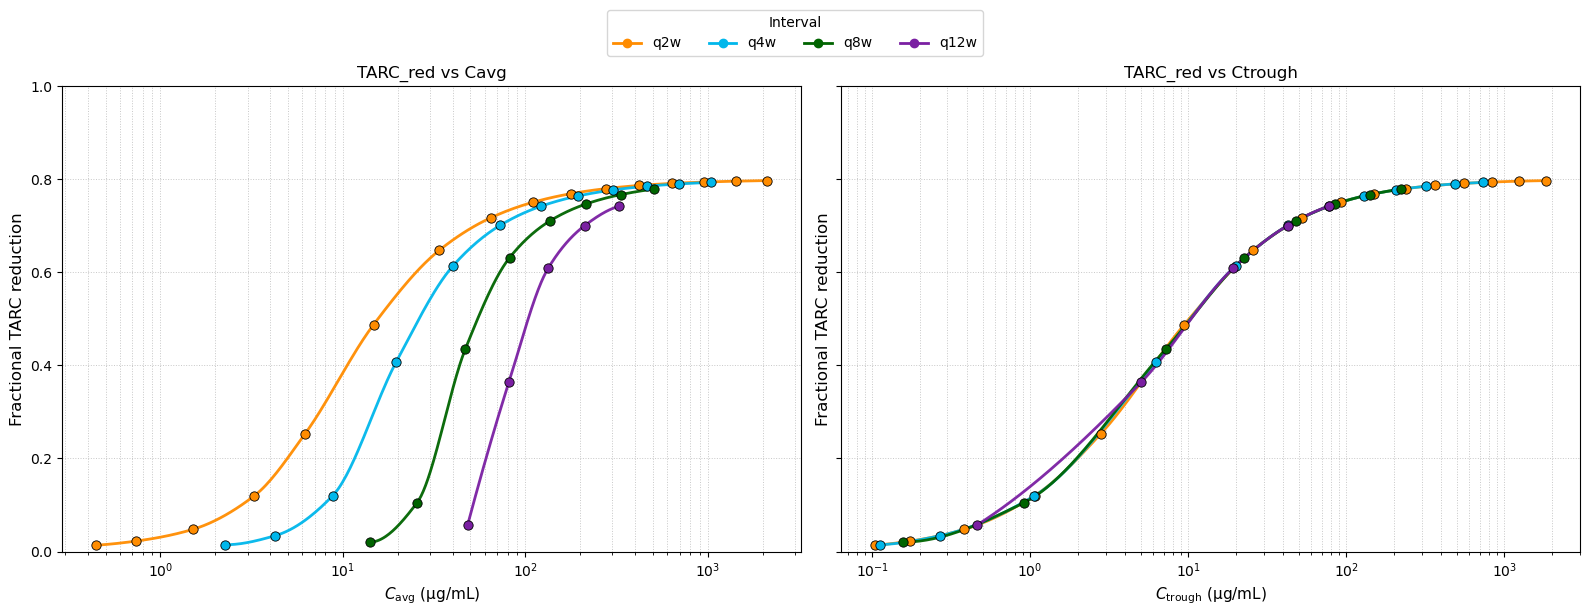

In [5]:
# Plotting-only thresholds to remove saturation (adjust as desired)
PD_MIN = 0.01
PD_MAX = 0.99

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterSciNotation
from scipy.interpolate import PchipInterpolator  # smooth, monotone-friendly spline

if df.empty:
    raise RuntimeError("DataFrame `df` is empty. Run the sweep or load summaries first.")

# --- Detect PD trough column automatically ---
pd_candidates = [c for c in df.columns if c.endswith("_trough") and c not in ["C_trough_ugml"]]
if "RO3_trough" in pd_candidates:
    pd_col = "RO3_trough"
elif "TARC_red_trough" in pd_candidates:
    pd_col = "TARC_red_trough"
elif len(pd_candidates) == 1:
    pd_col = pd_candidates[0]
else:
    raise RuntimeError(f"Could not determine PD trough column uniquely. Candidates: {pd_candidates}")

# Labels based on model
if pd_col == "RO3_trough":
    y_title = "Fraction of occupied IL-4R at SoA"
    plot_title_left = "RO3 vs Cavg"
    plot_title_right = "RO3 vs Ctrough"
elif pd_col == "TARC_red_trough":
    y_title = "Fractional TARC reduction"
    plot_title_left = "TARC_red vs Cavg"
    plot_title_right = "TARC_red vs Ctrough"
else:
    y_title = pd_col
    plot_title_left = f"{pd_col} vs Cavg"
    plot_title_right = f"{pd_col} vs Ctrough"

intervals = sorted(df["interval_weeks"].unique())

# User-defined interval colors (order corresponds to intervals sorted ascending)
base_colors = ["#FF8C00", "#00B7EB", "#006400", "#7A1FA2"]  # orange, cyan-blue, dark green, purple
colors = [base_colors[i % len(base_colors)] for i in range(len(intervals))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
ax_left, ax_right = axes

def smooth_curve_logx(x, y, n_points=250):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = x > 0
    if mask.sum() < 2:
        return None, None

    x = x[mask]
    y = y[mask]

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # If duplicate x values exist, average y (prevents spline errors)
    xu, inv = np.unique(x, return_inverse=True)
    if len(xu) != len(x):
        y_acc = np.zeros_like(xu, dtype=float)
        counts = np.zeros_like(xu, dtype=int)
        for i, idx in enumerate(inv):
            y_acc[idx] += y[i]
            counts[idx] += 1
        y = y_acc / counts
        x = xu

    if len(x) < 2:
        return None, None

    lx = np.log10(x)
    lx_min, lx_max = lx[0], lx[-1]
    if lx_max <= lx_min + 1e-12:
        return x, y

    lx_smooth = np.linspace(lx_min, lx_max, n_points)
    f = PchipInterpolator(lx, y)
    y_smooth = f(lx_smooth)
    x_smooth = 10 ** lx_smooth
    return x_smooth, y_smooth


legend_handles = []
for idx, iw in enumerate(intervals):
    dfi = df[df["interval_weeks"] == iw].copy()
    color = colors[idx]

    # PD values (same for both panels)
    y = dfi[pd_col].values.astype(float)
    pd_mask = (y >= PD_MIN) & (y <= PD_MAX)

    # --- Left: PD vs C_avg ---
    x_avg = dfi["C_avg_ugml"].values.astype(float)
    xs, ys = smooth_curve_logx(x_avg[pd_mask], y[pd_mask])
    if xs is not None:
        ax_left.plot(xs, ys, color=color, linewidth=2.0, alpha=0.95)

    ax_left.scatter(
        x_avg[pd_mask],
        y[pd_mask],
        color=color,
        edgecolor="k",
        linewidth=0.6,
        s=45,
        zorder=3,
    )

    # --- Right: PD vs C_trough ---
    x_tr = dfi["C_trough_ugml"].values.astype(float)
    xs, ys = smooth_curve_logx(x_tr[pd_mask], y[pd_mask])
    if xs is not None:
        ax_right.plot(xs, ys, color=color, linewidth=2.0, alpha=0.95)

    ax_right.scatter(
        x_tr[pd_mask],
        y[pd_mask],
        color=color,
        edgecolor="k",
        linewidth=0.6,
        s=45,
        zorder=3,
    )

    legend_handles.append(
        plt.Line2D([0], [0], color=color, lw=2, marker="o", markersize=6, label=f"q{iw}w")
    )

# Axes formatting
for ax in (ax_left, ax_right):
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.grid(which="both", linestyle=":", linewidth=0.7, alpha=0.7)

    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_major_formatter(LogFormatterSciNotation())
    ax.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

ax_left.set_title(plot_title_left, fontsize=12)
ax_right.set_title(plot_title_right, fontsize=12)

ax_left.set_xlabel(r"$C_{\mathrm{avg}}$ (µg/mL)", fontsize=11)
ax_right.set_xlabel(r"$C_{\mathrm{trough}}$ (µg/mL)", fontsize=11)

ax_left.set_ylabel(y_title, fontsize=12)
ax_right.set_ylabel(y_title, fontsize=12)

fig.legend(
    handles=legend_handles,
    title="Interval",
    loc="upper center",
    ncol=len(intervals),
    bbox_to_anchor=(0.5, 1.03),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
